# Public datasets: statistical analysis 

This notebook **only reads** images from the existing datasets in Folder format and produces descriptive statistics and plots.


## Expected folder layout (the only one supported here)

```
<root>/
  <dataset_root>/
    train/good/
    test/good/
    test/bad/   (files; defect encoded in filename)
```

**Defect name** is encoded in the filename in `test/bad` between `__ __`, e.g.:
`Manufacturing_defects__7_partially_erased__CAM1-...tif` → defect=`7_partially_erased`.

In [1]:
# ===================== 1) IMPORTS =====================
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

tqdm.disable = True


In [2]:
# ===================== 2) CONSTANTS / PATHS (edit here) =====================
# Point to the folders (outer directories) where the datasets are stored.
# The notebook will automatically find the inner <dataset_root> that contains train/ and test/.
ROOTS = {
    "circulation_quality": Path("./dataset_public_circulation_quality").resolve(),
    "manufacturing_defects": Path("./dataset_public_manufacturing_defects").resolve(),
}

# Where to optionally save plots/tables (analysis artifacts only)
OUTPUT_DIR = Path("./coindefect6k_analysis_outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
rng = np.random.default_rng(SEED)

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".TIF", ".TIFF",
}

UNKNOWN_DEFECT = "unknown"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

for k, p in ROOTS.items():
    print(k, '->', p)
    assert p.exists(), f"Dataset root not found: {p}"

print("OUTPUT_DIR:", OUTPUT_DIR)


circulation_quality -> /mnt/c/Users/szymo/Documents/Proditec/6kds/6kds/dataset_public_circulation_quality_freeze
manufacturing_defects -> /mnt/c/Users/szymo/Documents/Proditec/6kds/6kds/dataset_public_manufacturing_defects_freeze
OUTPUT_DIR: /home/sbk/Software/coindefect6k/coindefect6k_analysis_outputs


In [3]:
# ===================== 3) Helpers: resolve dataset root + parse defect =====================

def resolve_dataset_root(root: Path) -> Path:
    """Given <root>, find the nested <dataset_root> that contains train/ and test/."""
    root = Path(root)
    for cand in root.rglob('*'):
        if cand.is_dir() and (cand / 'train').is_dir() and (cand / 'test').is_dir():
            return cand
    raise FileNotFoundError(
        f"Could not find inner dataset root with train/ and test/ under {root}"
    )


def is_img(p: Path) -> bool:
    return p.is_file() and p.suffix in IMG_EXTS


def parse_defect_from_filename(filename: str) -> str:
    """Extract defect between double-underscore markers: __DEFECT__."""
    m = re.search(r'__([^_].*?)__', filename)
    return m.group(1) if m else UNKNOWN_DEFECT


In [4]:
# ===================== 4) INDEX FILES (Folder-format datasets) =====================

def build_index_df(roots: dict[str, Path]) -> pd.DataFrame:
    rows = []

    for ds_key, root in roots.items():
        dataset_root = resolve_dataset_root(root)

        split_specs = [
            ('train', 'good', 'good'),
            ('test', 'good', 'good'),
            ('test', 'bad',  'bad'),
        ]

        for split, subdir, label in split_specs:
            dir_path = dataset_root / split / subdir
            if not dir_path.exists():
                print(f"[WARN] Missing: {dir_path} (skipping)")
                continue

            for f in dir_path.rglob('*'):
                if not is_img(f):
                    continue

                defect = parse_defect_from_filename(f.name) if label == 'bad' else 'good'

                rows.append({
                    'dataset_key': ds_key,
                    'dataset_root': str(dataset_root),
                    'final_split': f"{split}/{subdir}",
                    'label_main': label,
                    'defect_type': defect,
                    'path': str(f.resolve()),
                })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError('No images indexed. Check ROOTS paths and folder structure.')

    df = df.sort_values(['dataset_key', 'final_split', 'label_main', 'defect_type', 'path']).reset_index(drop=True)
    df['is_bad'] = df['label_main'].eq('bad')
    return df


df = build_index_df(ROOTS)
print('Indexed images:', len(df))

summary_by_label = df.groupby(['dataset_key', 'final_split', 'label_main']).size().to_frame('count')
summary_by_defect = df.groupby(['dataset_key', 'final_split', 'label_main', 'defect_type']).size().to_frame('count')

print('\n--- By label ---')
display(summary_by_label)

print('\n--- By defect (bad only) ---')
display(summary_by_defect[summary_by_defect.index.get_level_values('label_main') == 'bad'])


Indexed images: 6003

--- By label ---


count
dataset_key           final_split label_main       
circulation_quality   test/bad    bad           495
                      test/good   good          801
                      train/good  good         3205
manufacturing_defects test/bad    bad           204
                      test/good   good          260
                      train/good  good         1038


--- By defect (bad only) ---


count
dataset_key           final_split label_main defect_type                     
circulation_quality   test/bad    bad        DAMAGED                      202
                                             DIRTY                        186
                                             OXIDIZED                     107
manufacturing_defects test/bad    bad        7_partially_erased            35
                                             Building_partially_erased     16
                                             Different_pressures          139
                                             Star_partially_erased         14

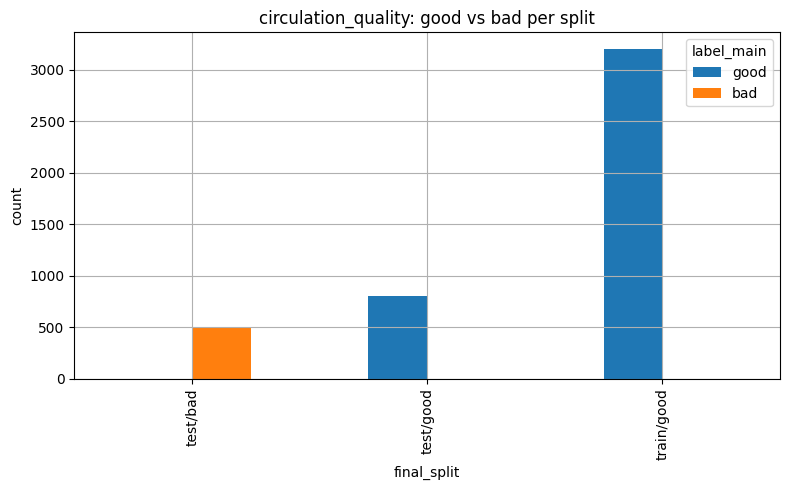

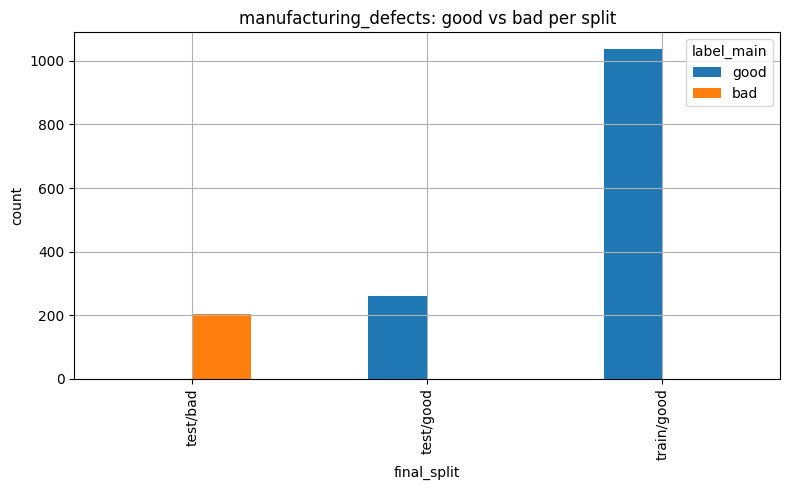

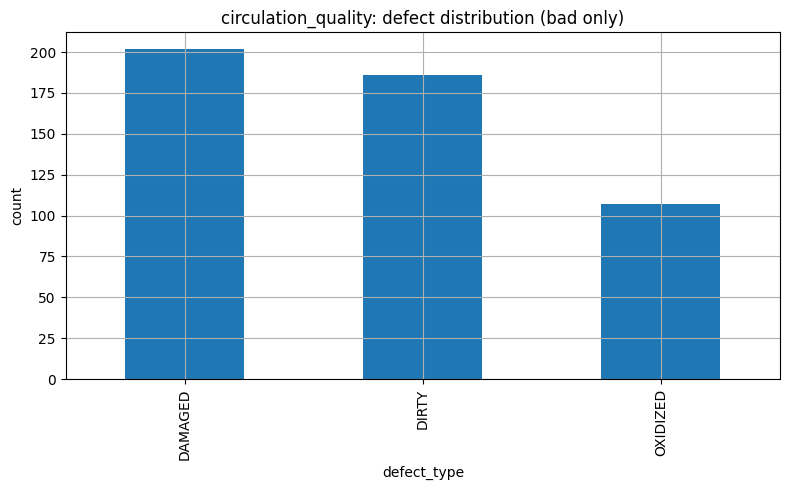

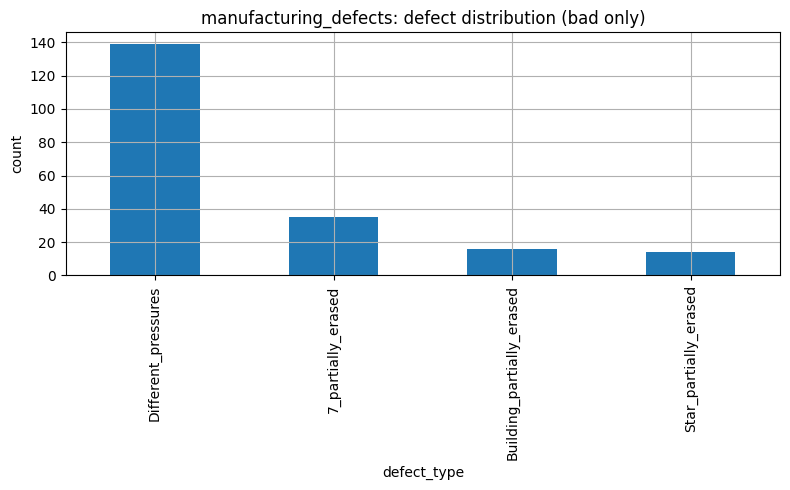

In [5]:
# ===================== 5) Quick plots =====================

pivot = (df.groupby(['dataset_key', 'final_split', 'label_main']).size()
         .unstack(fill_value=0)
         .reset_index())

for ds_key in pivot['dataset_key'].unique():
    tmp = pivot[pivot['dataset_key'] == ds_key].set_index('final_split')
    cols = [c for c in ['good', 'bad'] if c in tmp.columns]
    tmp[cols].plot(kind='bar', title=f'{ds_key}: good vs bad per split')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

for ds_key in df['dataset_key'].unique():
    tmp = df[(df['dataset_key'] == ds_key) & (df['label_main'] == 'bad')]
    if len(tmp) == 0:
        continue
    tmp['defect_type'].value_counts().plot(kind='bar', title=f'{ds_key}: defect distribution (bad only)')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_202040/944288725.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_sample_group)


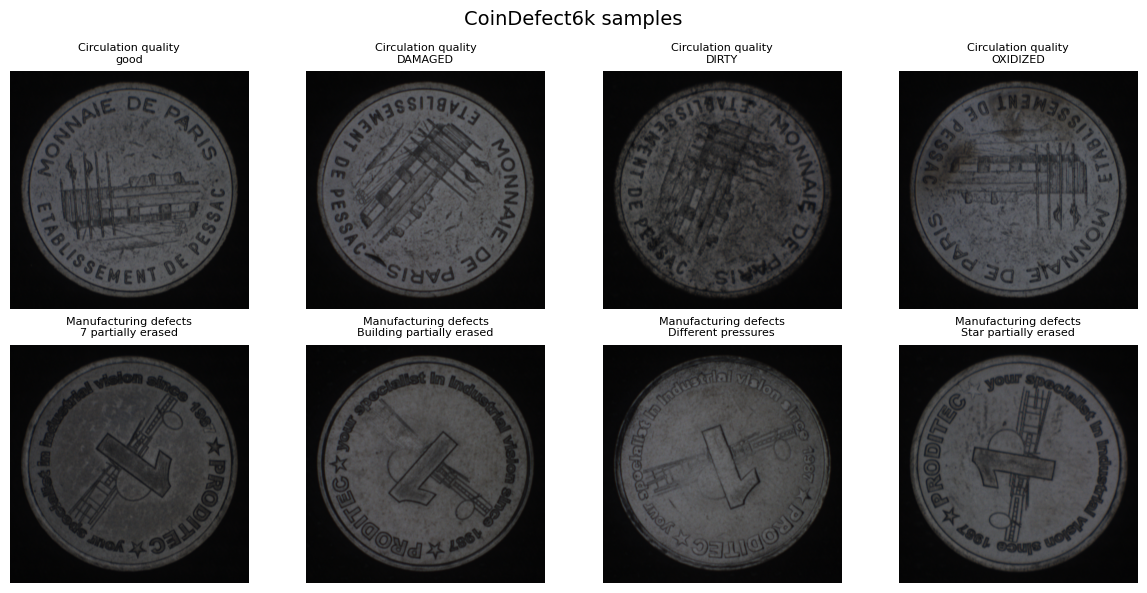

In [12]:
# ===================== 6) Sample grid (bad only) =====================
# ===================== 6) Sample grid (all classes: defects + normal) =====================

def show_sample_grid(df_in, n=12, title='Samples', filename=None, ensure_all_classes=False, per_class=1):
    if len(df_in) == 0:
        print('No images to show')
        return

    # --- NEW: ensure we show good + all defect types (per dataset_key) ---
    if ensure_all_classes:
        # one (or per_class) sample(s) per (dataset_key, defect_type)
        def _sample_group(g):
            k = min(per_class, len(g))
            # make sampling deterministic per group
            return g.sample(k, random_state=SEED)

        sample = (
            df_in
            .groupby(['dataset_key', 'defect_type'], group_keys=False)
            .apply(_sample_group)
            .reset_index(drop=True)
        )

        # Optional: put "good" first within each dataset, then alphabetical
        sample['__is_good'] = (sample['defect_type'] == 'good').astype(int)
        sample = sample.sort_values(['dataset_key', '__is_good', 'defect_type'], ascending=[True, False, True])
        sample = sample.drop(columns='__is_good')

    else:
        # original behavior: random sample
        sample = df_in.sample(min(n, len(df_in)), random_state=SEED)

    ncols = 4
    nrows = int(np.ceil(len(sample) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for ax in axes.flat:
        ax.axis('off')

    for i, (_, row) in enumerate(sample.iterrows()):
        r, c = divmod(i, ncols)
        img = Image.open(row['path']).convert('RGB')
        axes[r, c].imshow(img)
        axes[r, c].set_title(
            f"{row['dataset_key'].replace('_', ' ').capitalize()}\n{row['defect_type'].replace('_', ' ')}",
            fontsize=8
        )

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if filename:
        plt.savefig(OUTPUT_DIR / filename, bbox_inches='tight', format='pdf')
    plt.show()


df_vis = pd.concat([
    df[df.label_main == 'bad'],
    df[(df.label_main == 'good') & (df['dataset_key'].str.contains('circulation', case=False, na=False))]
], ignore_index=True)


show_sample_grid(df_vis, n=8, title='CoinDefect6k samples', ensure_all_classes=True,filename='bad_samples.pdf')
